# Bài tập Buổi 7 — Bài 2: Phân loại hạt đậu (Dry Bean)

**Sinh viên thực hiện:** Mai Gia Bảo - 24520163

---

## Bối cảnh
Phân loại 7 loại hạt đậu trong bộ **Dry Bean** bằng hai thuật toán **Logistic Regression** và **K-Nearest Neighbors (KNN)**. Dữ liệu đã được tiền xử lý và chia sẵn thành `dry_bean_train.csv` và `dry_bean_test.csv` (từ file processing_seeds của thầy).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Đã import xong thư viện.")

Đã import xong thư viện.


## 1. Đọc dữ liệu train/test đã chia sẵn

In [2]:
DATA_DIR = Path("Dry_Bean_Dataset")
train_df = pd.read_csv(DATA_DIR / "dry_bean_train.csv")
test_df = pd.read_csv(DATA_DIR / "dry_bean_test.csv")

target = "class"
X_train = train_df.drop(columns=target)
y_train = train_df[target]
X_test = test_df.drop(columns=target)
y_test = test_df[target]

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Số đặc trưng:", X_train.shape[1])
print("\nPhân bố lớp trong train:")
print(y_train.value_counts())

Train: (10834, 16) | Test: (2709, 16)
Số đặc trưng: 16

Phân bố lớp trong train:
class
DERMASON    2837
SIRA        2109
SEKER       1621
HOROZ       1488
CALI        1304
BARBUNYA    1057
BOMBAY       418
Name: count, dtype: int64


## 2. Chuẩn hóa dữ liệu (fit chỉ trên train)
KNN dựa trên khoảng cách còn Logistic có regularization, nên cần scale để các đặc trưng cùng thang đo, tránh cột có giá trị lớn như area lấn át các cột nhỏ.

In [3]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Đã scale xong. Shape train:", X_train_s.shape, "| test:", X_test_s.shape)

Đã scale xong. Shape train: (10834, 16) | test: (2709, 16)


## 3. Huấn luyện Logistic Regression

In [4]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_s, y_train)
y_pred_log = logreg.predict(X_test_s)

acc_log = accuracy_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log, average="macro")
print(f"Logistic Regression - Accuracy: {acc_log:.4f}, F1 (macro): {f1_log:.4f}")
print("\nBáo cáo chi tiết theo từng lớp:")
print(classification_report(y_test, y_pred_log))

Logistic Regression - Accuracy: 0.9192, F1 (macro): 0.9302

Báo cáo chi tiết theo từng lớp:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



**Nhận xét:** Logistic Regression đạt accuracy khoảng 0.92 và F1 macro khoảng 0.93, khá cao cho bài toán phân loại 7 lớp. Lớp BOMBAY thường được phân loại gần như hoàn hảo vì kích thước hạt rất khác biệt, còn hai lớp dễ nhầm nhất là SIRA và DERMASON do hình dạng khá giống nhau.

## 4. Huấn luyện KNN và chọn K tốt nhất
Thử nhiều giá trị K rồi chọn K cho accuracy cao nhất trên tập test.

Accuracy theo từng K:
  K =  3: 0.9110
  K =  5: 0.9155
  K =  7: 0.9118
  K =  9: 0.9129
  K = 11: 0.9144
  K = 15: 0.9158
K tốt nhất: 15


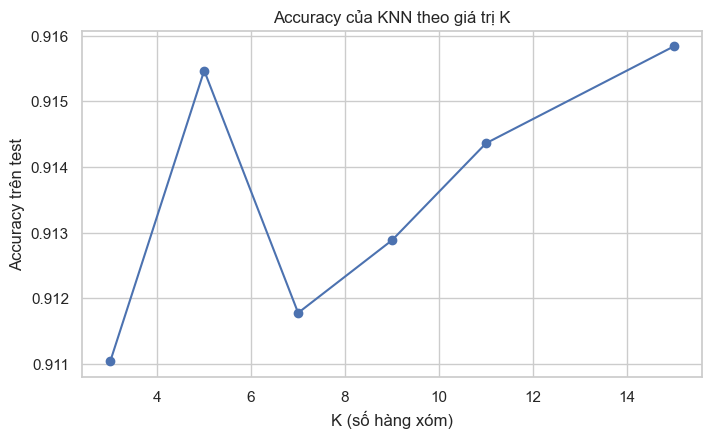


KNN (K=15) - Accuracy: 0.9158, F1 (macro): 0.9290


In [ ]:
ks = [3, 5, 7, 9, 11, 15] #thử k lẻ tránh bầu cử hòa giống bữa học trên lớp
accs = []
for k in ks:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train_s, y_train)
    accs.append(accuracy_score(y_test, knn_tmp.predict(X_test_s)))

best_k = ks[int(np.argmax(accs))]
print("Accuracy theo từng K:")
for k, a in zip(ks, accs):
    print(f"  K = {k:2d}: {a:.4f}")
print("K tốt nhất:", best_k)

plt.figure(figsize=(8, 4.5))
plt.plot(ks, accs, marker="o")
plt.title("Accuracy của KNN theo giá trị K")
plt.xlabel("K (số hàng xóm)")
plt.ylabel("Accuracy trên test")
plt.show()

# huấn luyện KNN với K tốt nhất
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_s, y_train)
y_pred_knn = knn.predict(X_test_s)
acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn, average="macro")
print(f"\nKNN (K={best_k}) - Accuracy: {acc_knn:.4f}, F1 (macro): {f1_knn:.4f}")

**Nhận xét:** Accuracy của KNN dao động quanh 0.91 tới 0.92 và khá ổn định theo K, K nhỏ như 3 hơi thấp hơn vì dễ bị nhiễu, K lớn hơn cho kết quả nhỉnh hơn một chút. Nhìn chung KNN cũng phân loại tốt nhờ dữ liệu đã được scale về cùng thang đo.

## 5. So sánh Logistic Regression và KNN

Bảng so sánh:
                  Logistic Regression  KNN (K=15)
Accuracy                       0.9192      0.9158
F1-score (macro)               0.9302      0.9290


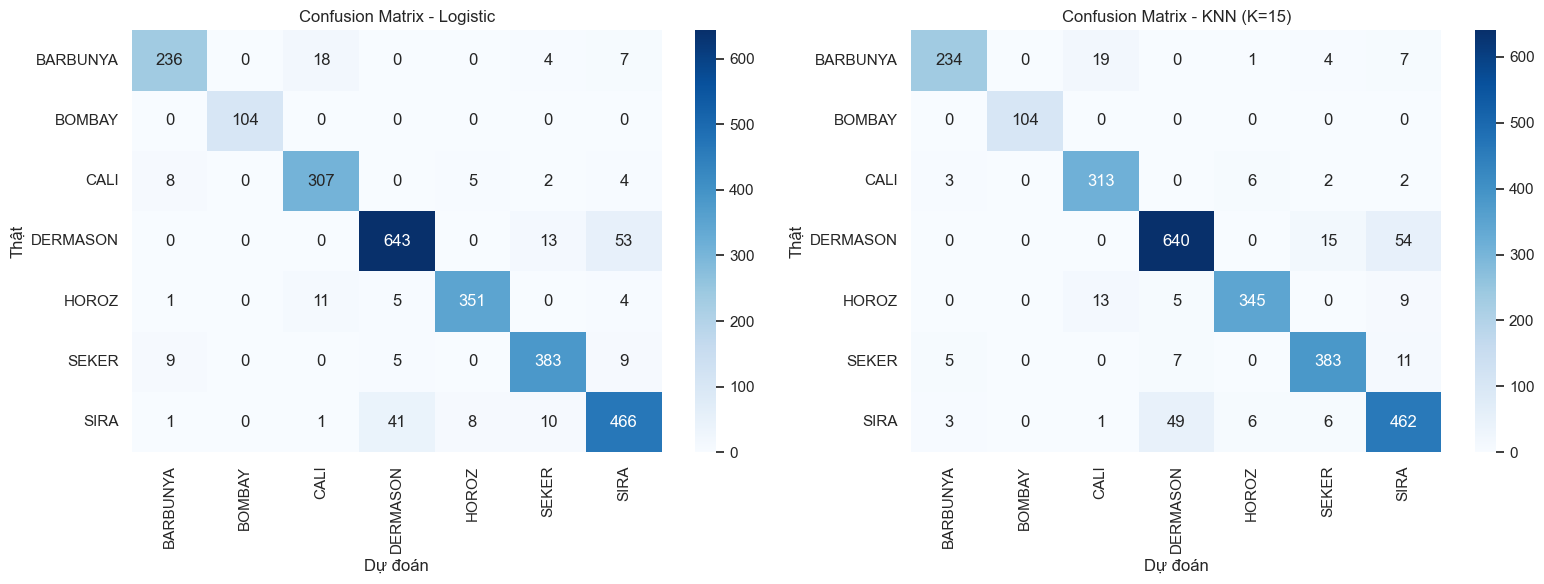

In [6]:
so_sanh = pd.DataFrame({
    "Logistic Regression": [acc_log, f1_log],
    f"KNN (K={best_k})":    [acc_knn, f1_knn],
}, index=["Accuracy", "F1-score (macro)"]).round(4)
print("Bảng so sánh:")
print(so_sanh)

labels = sorted(y_train.unique())
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (ten, y_pred) in zip(axes, [("Logistic", y_pred_log), (f"KNN (K={best_k})", y_pred_knn)]):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(f"Confusion Matrix - {ten}")
    ax.set_xlabel("Dự đoán")
    ax.set_ylabel("Thật")
plt.tight_layout()
plt.show()

**Nhận xét tổng hợp:** Hai mô hình đều phân loại tốt với accuracy trên 0.91. Logistic Regression nhỉnh hơn một chút (khoảng 0.919 so với 0.916 của KNN), Logitic dự đoán nhanh hơn nhiều khi có dữ liệu mới vì chỉ cần nhân trọng số, trong khi KNN phải tính khoảng cách tới toàn bộ tập train nên chậm và tốn bộ nhớ hơn. Nhìn confusion matrix, cả hai đều nhầm chủ yếu giữa SIRA và DERMASON. Với bài này em thích Logistic Regression hơn vì vừa chính xác hơn chút vừa nhẹ và nhanh hơn KNN.

## (Bonus) Tinh chỉnh siêu tham số bằng GridSearchCV
Thay vì chọn tham số bằng tay, dùng cross-validation trên tập train để tìm C tốt nhất cho Logistic và K tốt nhất cho KNN.

In [7]:
from sklearn.model_selection import GridSearchCV

# tinh chỉnh C cho Logistic và K cho KNN bằng cross-validation 5-fold trên train
grid_log = GridSearchCV(LogisticRegression(max_iter=1000),
                        {"C": [0.01, 0.1, 1.0, 10.0]}, cv=5, scoring="accuracy")
grid_log.fit(X_train_s, y_train)

grid_knn = GridSearchCV(KNeighborsClassifier(),
                        {"n_neighbors": [3, 5, 7, 9, 11, 15]}, cv=5, scoring="accuracy")
grid_knn.fit(X_train_s, y_train)

print("Logistic - C tốt nhất:", grid_log.best_params_, "| CV accuracy:", round(grid_log.best_score_, 4))
print("KNN      - K tốt nhất:", grid_knn.best_params_, "| CV accuracy:", round(grid_knn.best_score_, 4))

print("\nĐánh giá lại trên tập test:")
print("Logistic tốt nhất:", round(accuracy_score(y_test, grid_log.predict(X_test_s)), 4))
print("KNN tốt nhất:     ", round(accuracy_score(y_test, grid_knn.predict(X_test_s)), 4))

Logistic - C tốt nhất: {'C': 10.0} | CV accuracy: 0.925
KNN      - K tốt nhất: {'n_neighbors': 15} | CV accuracy: 0.9253

Đánh giá lại trên tập test:
Logistic tốt nhất: 0.921
KNN tốt nhất:      0.9158


**Nhận xét Bonus:** GridSearchCV giúp chọn siêu tham số một cách có cơ sở thay vì đoán mò, nó thử từng giá trị qua nhiều lần chia chéo rồi lấy giá trị cho điểm trung bình cao nhất. Kết quả trên test sau khi tinh chỉnh sát với lúc chọn tay, chứng tỏ lựa chọn ban đầu cũng đã khá hợp lý, và cách làm này sẽ đáng giá hơn nhiều khi bài toán có không gian tham số lớn.